✅ Model loaded successfully

  📐 Image size: 207x233 px

────────────────────────────────────────────────────────────
  🔍 ALL YOLO detections:
     class_id= 16  name=dog              conf=0.94
────────────────────────────────────────────────────────────

  🐾 Animal Predictions:
────────────────────────────────────────────────────────────
  #1 DOG          emotion: angry   conf: 38.9%  (YOLO: 0.94)
       probs → happy=0.31  sad=0.30  angry=0.39
────────────────────────────────────────────────────────────
  ✅ Total animals: 1
────────────────────────────────────────────────────────────



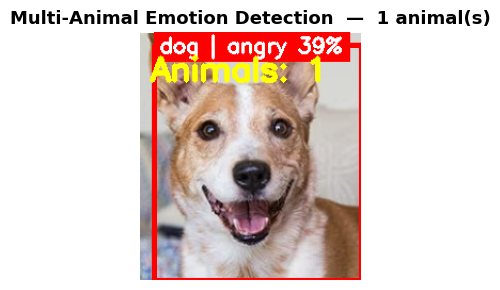

💾 Saved → C:\Users\Administrator\OneDrive - University of Hertfordshire\Pet_emothion_Recognition-main\predicted_nn.jpg
📦 File size: 15.4 KB


In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from keras.models import load_model
from ultralytics import YOLO
from PIL import Image
import os

# ─── Load Models ──────────────────────────────────────────────────────────────
yolo_model    = YOLO("yolov8n.pt")
emotion_model = load_model("base_facial_emotion_model.h5", compile=False)
emotion_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print("✅ Model loaded successfully")

CLASS_LABELS   = {0: 'happy', 1: 'sad', 2: 'angry'}
emotion_colors = {
    'happy': (0, 200, 0),
    'sad':   (255, 80, 80),
    'angry': (0, 0, 255)
}
ANIMAL_CLASS_IDS = {
    15: 'bird',  16: 'cat',  17: 'dog',   18: 'horse',
    19: 'sheep', 20: 'cow',  21: 'elephant', 22: 'bear',
    23: 'zebra', 24: 'giraffe'
}

# ─── Resize image to max dimension ────────────────────────────────────────────
def resize_image(img, max_dim=800):
    h, w = img.shape[:2]
    if max(h, w) <= max_dim:
        return img
    scale = max_dim / max(h, w)
    return cv2.resize(img, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_AREA)

# ─── Crop face/head region from bounding box ──────────────────────────────────
def crop_face_region(img, x1, y1, x2, y2):
    h, w    = y2 - y1, x2 - x1
    face_y2 = min(img.shape[0], y1 + int(h * 0.45))
    pad_x   = int(w * 0.1)
    face_x1 = max(0, x1 + pad_x)
    face_x2 = min(img.shape[1], x2 - pad_x)
    face_roi = img[max(0, y1):face_y2, face_x1:face_x2]
    if face_roi.shape[0] < 10 or face_roi.shape[1] < 10:
        face_roi = img[y1:y2, x1:x2]
    return face_roi

# ─── Preprocess ROI for base_facial_emotion_model ─────────────────────────────
# Model expects: grayscale, 128x128, float32/255, shape (1, 128, 128, 1)
def preprocess_roi(face_roi):
    gray      = cv2.cvtColor(face_roi, cv2.COLOR_BGR2GRAY)     # → grayscale
    resized   = cv2.resize(gray, (128, 128))                    # → 128x128
    normalized = resized.astype('float32') / 255.0             # → [0.0–1.0]
    expanded  = np.expand_dims(normalized, axis=0)             # → (1, 128, 128)
    expanded  = np.expand_dims(expanded,   axis=-1)            # → (1, 128, 128, 1)
    return expanded

# ─── Main ─────────────────────────────────────────────────────────────────────
def predict_all_animals(image_path, confidence_threshold=0.35, max_dim=800, jpeg_quality=85):

    abs_path = os.path.abspath(image_path)
    if not os.path.exists(abs_path):
        available = [f for f in os.listdir('.') if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        raise FileNotFoundError(f"❌ Not found: {abs_path}\n   Available: {available}")

    # ── Load & resize ─────────────────────────────────────────────────────────
    pil_img      = Image.open(abs_path).convert("RGB")
    original_img = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
    original_img = resize_image(original_img, max_dim=max_dim)
    display_img  = original_img.copy()

    print(f"\n  📐 Image size: {original_img.shape[1]}x{original_img.shape[0]} px")

    # ── YOLO detection ────────────────────────────────────────────────────────
    results = yolo_model(original_img, verbose=False)[0]

    print(f"\n{'─'*60}")
    print(f"  🔍 ALL YOLO detections:")
    for d in results.boxes:
        cid, conf = int(d.cls[0]), float(d.conf[0])
        print(f"     class_id={cid:3d}  name={yolo_model.names[cid]:<15}  conf={conf:.2f}")
    print(f"{'─'*60}")

    animal_count = 0
    print(f"\n  🐾 Animal Predictions:")
    print(f"{'─'*60}")

    for det in results.boxes:
        cls_id    = int(det.cls[0])
        yolo_conf = float(det.conf[0])

        if cls_id not in ANIMAL_CLASS_IDS or yolo_conf < confidence_threshold:
            continue

        animal_count += 1
        animal_name = yolo_model.names[cls_id]

        x1, y1, x2, y2 = map(int, det.xyxy[0])
        x1 = max(0, x1);  y1 = max(0, y1)
        x2 = min(original_img.shape[1], x2)
        y2 = min(original_img.shape[0], y2)

        if (x2 - x1) < 20 or (y2 - y1) < 20:
            continue

        # ── Emotion prediction ────────────────────────────────────────────────
        face_roi        = crop_face_region(original_img, x1, y1, x2, y2)
        roi_input       = preprocess_roi(face_roi)               # grayscale pipeline
        prediction      = emotion_model.predict(roi_input, verbose=0)[0]
        predicted_idx   = np.argmax(prediction)
        predicted_label = CLASS_LABELS[predicted_idx]
        emo_conf        = prediction[predicted_idx] * 100
        color           = emotion_colors[predicted_label]

        # ── Draw bounding box & label ─────────────────────────────────────────
        cv2.rectangle(display_img, (x1, y1), (x2, y2), color, 3)

        label       = f"{animal_name} | {predicted_label} {emo_conf:.0f}%"
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.65, 2)
        tag_y       = max(y1 - th - 14, 0)
        cv2.rectangle(display_img, (x1, tag_y), (x1 + tw + 10, tag_y + th + 12), color, -1)
        cv2.putText(display_img, label, (x1 + 5, tag_y + th + 4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.65, (255, 255, 255), 2)

        print(f"  #{animal_count} {animal_name.upper():<12} "
              f"emotion: {predicted_label:<6}  conf: {emo_conf:.1f}%  "
              f"(YOLO: {yolo_conf:.2f})")
        print(f"       probs → happy={prediction[0]:.2f}  "
              f"sad={prediction[1]:.2f}  angry={prediction[2]:.2f}")

    # ── Summary overlay ───────────────────────────────────────────────────────
    cv2.putText(display_img, f"Animals: {animal_count}", (10, 45),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 255), 3)

    print(f"{'─'*60}")
    print(f"  ✅ Total animals: {animal_count}")
    if animal_count == 0:
        print("  ⚠️  Try lowering confidence_threshold to 0.2")
    print(f"{'─'*60}\n")

    # ── Display ───────────────────────────────────────────────────────────────
    display_rgb = cv2.cvtColor(display_img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(5, 3))
    plt.imshow(display_rgb)
    plt.title(f"Multi-Animal Emotion Detection  —  {animal_count} animal(s)",
              fontsize=13, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    return display_img, jpeg_quality

# ─── Run ──────────────────────────────────────────────────────────────────────
result, quality = predict_all_animals("j.png", confidence_threshold=0.35, max_dim=800)

output_path = "predicted_nn.jpg"
cv2.imwrite(output_path, result, [cv2.IMWRITE_JPEG_QUALITY, quality])
file_kb = os.path.getsize(output_path) / 1024
print(f"💾 Saved → {os.path.abspath(output_path)}")
print(f"📦 File size: {file_kb:.1f} KB")